# 01 - Size and tie effect (paper Fig 4, Table 1)

Reproduces the paper's core replication: RTs grow with the product of the
operands (size effect), tie problems (e.g. 4x4) are faster than non-tie
problems of similar size (tie effect), and the size effect is smaller for
ties (size x tie interaction).

Restricted to 1-digit-by-1-digit trials, correct answers only, with the
paper's outlier rule applied (time_taken within 4 SD of the per-category
mean).


In [1]:
# Data source toggle. The live backend DB has zero trial_results as of
# 2026-09 (see ../DATA_GAPS.md) -- this app just went public. Flip
# USE_SYNTHETIC to False once real rows exist; every cell below is written
# against the DataFrame shape returned by moravec_analysis.data, so nothing
# else needs to change.
USE_SYNTHETIC = False

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from moravec_analysis.data import load_trial_results
from moravec_analysis.features import add_all_derived_fields, filter_rt_outliers
from moravec_analysis.synth import generate_synthetic_trials

if USE_SYNTHETIC:
    raw = generate_synthetic_trials(n_users=400, trials_per_user=150, seed=7)
else:
    raw = load_trial_results()  # defaults to apps/backend/data/moravec.sqlite

df = add_all_derived_fields(raw)
print(f"{len(df):,} trials, {df.email_hash.nunique():,} users")
df.head()


410 trials, 1 users


,id,email_hash,level_number,category_codename,operands,answer,correct,time_exceeded,time_taken,played_at,...,has_five,op1_gt_op2,unordered_pair,presented_pair,is_rhyme_pair,presented_in_rhyme_order,is_rhyme_control_pair,presented_in_control_order,table_distance_1,numeric_distance_le_2
0,b71489e4-4089-48fb-91c8-57018effab49,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[5, 3]",8,True,False,1376,2026-09-02 14:20:30.456,...,True,True,"(3, 5)","(5, 3)",False,False,True,False,<NA>,<NA>
1,ff1c2b76-e8c9-4244-81d7-0bc393f456fa,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[4, 6]",10,True,False,1384,2026-09-02 14:20:31.840,...,False,False,"(4, 6)","(4, 6)",True,False,False,False,<NA>,<NA>
2,e69af72d-ab35-434f-8cc6-083e1554cd64,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[8, 5]",13,True,False,1581,2026-09-02 14:20:33.421,...,True,True,"(5, 8)","(8, 5)",False,False,False,False,<NA>,<NA>
3,e027f4db-5f97-4e4c-af89-ee8028b725cf,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1dx1d,"[9, 4]",36,True,False,2145,2026-09-02 14:20:35.566,...,False,True,"(4, 9)","(9, 4)",False,False,False,False,<NA>,<NA>
4,12772bbc-689d-4107-bb36-0092ee87088a,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1dx1d,"[7, 7]",49,True,False,1259,2026-09-02 14:20:36.825,...,False,False,"(7, 7)","(7, 7)",False,False,False,False,<NA>,<NA>


In [2]:
one_by_one = df[df["category_codename"].isin(["1d+1d", "1dx1d"]) & df["correct"]]
clean = filter_rt_outliers(one_by_one, group_col="category_codename", sd=4.0)
print(f"{len(clean):,} / {len(one_by_one):,} trials kept after 4-SD RT filter")


188 / 189 trials kept after 4-SD RT filter


## Fig 4 -- RT vs product of operands, tie vs non-tie

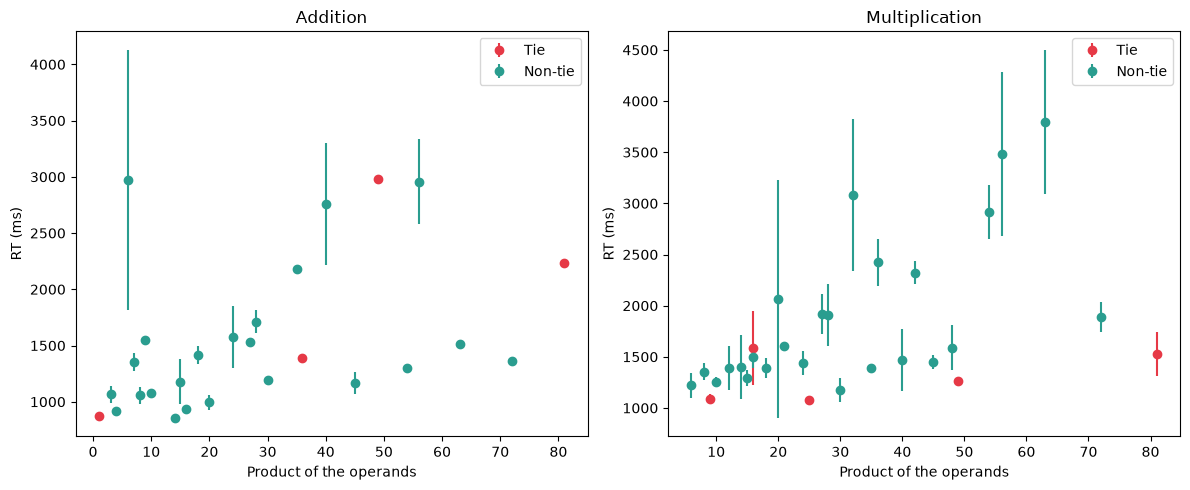

In [3]:
def plot_size_tie(data, category, title, ax):
    sub = data[data["category_codename"] == category]
    for is_tie, color, label in [(True, "#e63946", "Tie"), (False, "#2a9d8f", "Non-tie")]:
        g = sub[sub["is_tie"] == is_tie].groupby("product")["time_taken"]
        means, sems = g.mean(), g.sem()
        ax.errorbar(means.index, means.values, yerr=sems.values, fmt="o", color=color, label=label)
    ax.set_xlabel("Product of the operands")
    ax.set_ylabel("RT (ms)")
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_size_tie(clean, "1d+1d", "Addition", axes[0])
plot_size_tie(clean, "1dx1d", "Multiplication", axes[1])
plt.tight_layout()
plt.show()


## Table 1 -- mixed-effects regression

`time_taken ~ product * is_tie`, with by-subject random intercept and
random slope on `product` -- same specification as the paper. Run
separately per category (addition / multiplication).


In [4]:
import statsmodels.formula.api as smf

def fit_size_tie_model(data, category):
    sub = data[data["category_codename"] == category].copy()
    sub["is_tie"] = sub["is_tie"].astype(int)
    model = smf.mixedlm(
        "time_taken ~ product * is_tie",
        data=sub,
        groups=sub["email_hash"],
        re_formula="~product",
    )
    return model.fit(reml=False)


for category, label in [("1d+1d", "Addition"), ("1dx1d", "Multiplication")]:
    result = fit_size_tie_model(clean, category)
    print(f"=== {label} ===")
    print(result.summary().tables[1])
    print()


/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_871650/1362462865.py:12: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  return model.fit(reml=False)
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_871650/1362462865.py:12: ConvergenceWarning: Retrying MixedLM optimization with cg
  return model.fit(reml=False)
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/

=== Addition ===
                        Coef. Std.Err.       z  P>|z|     [0.025    0.975]
Intercept            1312.181  163.462   8.027  0.000    991.801  1632.562
product                10.328   11.638   0.887  0.375    -12.483    33.138
is_tie               -358.423  496.130  -0.722  0.470  -1330.820   613.974
product:is_tie         11.001   11.525   0.955  0.340    -11.588    33.590
Group Var             441.742                                             
Group x product Cov   -15.424                                             
product Var           109.767                                             

=== Multiplication ===
                        Coef. Std.Err.       z  P>|z|    [0.025    0.975]
Intercept            1010.502  130.878   7.721  0.000   753.986  1267.019
product                26.346    5.443   4.840  0.000    15.678    37.014
is_tie                226.623  350.749   0.646  0.518  -460.831   914.078
product:is_tie        -23.003    7.982  -2.882  0.004   -38.647

/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_871650/1362462865.py:12: ConvergenceWarning: Retrying MixedLM optimization with cg
  return model.fit(reml=False)
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_871650/1362462865.py:12: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  return model.fit(reml=False)
/tmp/ipykernel_871650/1362462865.py:12: ConvergenceWarning: Gradient optimization failed, |grad| = 150.224967
  return model.fit(reml=False)
/tmp/ipykernel_871650/1362462865.py:12: ConvergenceWarning: The Hessian matrix 

**Reading this**: a significant `product:is_tie` interaction term is the
size x tie interaction effect. A significant negative `is_tie` main effect
alone (holding product constant) is the tie effect. The `product`
coefficient is the size effect's slope, in ms per unit of product -- compare
against the paper's Table 1 (23.7 ms/u for addition non-ties, 35.0 ms/u for
multiplication non-ties).
